In [2]:
import zipfile
zip_ref=zipfile.ZipFile('/content/archive.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("/content/collegePlacement_data_10000_rows.csv")

In [5]:
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8.0,1,1,1
1,21,Female,Computer Science,0,7.0,1,1,1
2,22,Female,Information Technology,1,6.0,0,0,1
3,21,Male,Information Technology,0,8.0,0,1,1
4,22,Male,Mechanical,0,8.0,1,0,1


In [6]:
df=df[['Internships','CGPA','HistoryOfBacklogs','PlacedOrNot']]

In [7]:
df.head()

,Internships,CGPA,HistoryOfBacklogs,PlacedOrNot
0,1,8.0,1,1
1,0,7.0,1,1
2,1,6.0,0,1
3,0,8.0,1,1
4,0,8.0,0,1


In [8]:
#steps
#preprocess=eda+feature selection
#extract input and output cols
#scale the values
#train the split
#train the model
#evaluate the model/model selection
#deploy the model

In [9]:
df.info

<bound method DataFrame.info of       Internships  CGPA  HistoryOfBacklogs  PlacedOrNot
0               1  8.00                  1            1
1               0  7.00                  1            1
2               1  6.00                  0            1
3               0  8.00                  1            1
4               0  8.00                  0            1
...           ...   ...                ...          ...
9995            0  7.17                  1            0
9996            0  7.19                  0            1
9997            0  5.94                  1            0
9998            0  8.20                  0            1
9999            0  7.13                  0            1

[10000 rows x 4 columns]>

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Internships        10000 non-null  int64  
 1   CGPA               10000 non-null  float64
 2   HistoryOfBacklogs  10000 non-null  int64  
 3   PlacedOrNot        10000 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 312.6 KB


In [11]:
import matplotlib.pyplot as plt

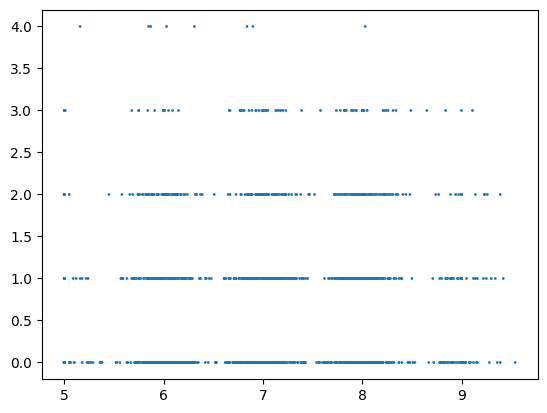

In [12]:
plt.scatter(df['CGPA'],df['Internships'],df['HistoryOfBacklogs'])

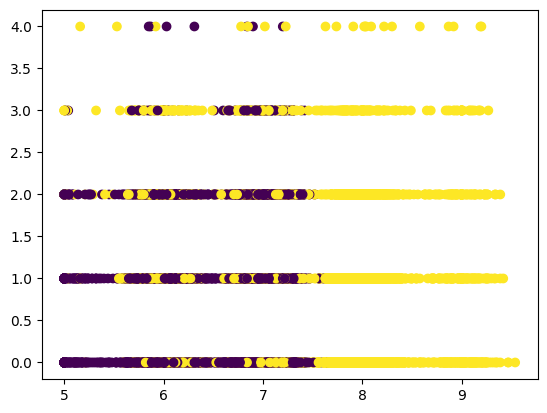

In [14]:
plt.scatter(df['CGPA'],df['Internships'],c=df['PlacedOrNot'])

In [15]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [16]:
x

,Internships,CGPA
0,1,8.00
1,0,7.00
2,1,6.00
3,0,8.00
4,0,8.00
...,...,...
9995,0,7.17
9996,0,7.19
9997,0,5.94
9998,0,8.20


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [20]:
x_train

,Internships,CGPA
4814,0,9.11
3903,0,5.88
4017,0,9.12
4991,0,8.10
677,0,7.00
...,...,...
3578,3,6.08
9898,1,7.06
9865,0,7.99
4337,0,6.09


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler=StandardScaler()

In [23]:
x_train=scaler.fit_transform(x_train)

In [24]:
x_train

array([[-0.92122071,  2.10425714],
       [-0.92122071, -1.22179521],
       [-0.92122071,  2.11455451],
       ...,
       [-0.92122071,  0.95095106],
       [-0.92122071, -1.00555032],
       [ 0.23918957,  0.96124844]])

In [25]:
x_test=scaler.transform(x_test)

In [26]:
x_test

array([[ 2.56001012,  0.0859715 ],
       [ 0.23918957, -1.0982267 ],
       [ 0.23918957,  0.65232717],
       ...,
       [-0.92122071,  0.67292192],
       [-0.92122071, -0.24354452],
       [-0.92122071, -0.20235502]])

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf=LogisticRegression()

In [29]:
#model training
clf.fit(x_train,y_train)

LogisticRegression()

In [30]:
y_pred=clf.predict(x_test)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,y_pred)

0.7555

In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

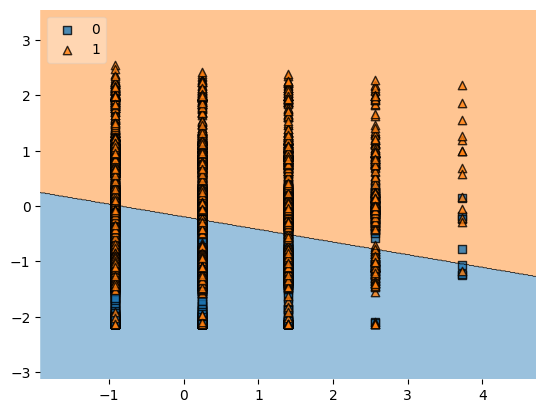

In [36]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [37]:
import pickle

In [38]:
pickle.dump(clf,open('model.pkl','wb'))